# Investigating HLCA Annotation Hierarchy Structure

This notebook analyzes the raw annotation hierarchy in the lung dataset to understand:
- Which annotation level is truly the broadest (level 1) and deepest (level 5)
- Whether the hierarchy is monotonically increasing in specificity
- Why some cell type relationships are inverted
- How to properly structure the hierarchy for HCE training

Key assumption: **ann_level_1 should be broadest (fewest unique values, highest generality)**
**ann_level_5 should be deepest (most unique values, highest specificity)**

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration
LUNG_H5AD_PATH = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad'

print("✅ Libraries imported")

✅ Libraries imported


## 1. Load the Raw Data

In [2]:
print("Loading lung.h5ad data...")
adata = sc.read_h5ad(LUNG_H5AD_PATH, backed='r')
print(f"✅ Data loaded: {adata.shape}")
print(f"\nAnnotation columns in dataset:")
ann_cols = [col for col in adata.obs.columns if col.startswith('ann_level_')]
for col in sorted(ann_cols):
    print(f"  ✓ {col}")

# Extract annotation data
print(f"\nExtracting annotation data...")
ann_data = adata.obs[sorted(ann_cols)].copy()
print(f"Annotation dataframe shape: {ann_data.shape}")

Loading lung.h5ad data...
✅ Data loaded: (2282447, 55329)

Annotation columns in dataset:
  ✓ ann_level_1
  ✓ ann_level_2
  ✓ ann_level_3
  ✓ ann_level_4
  ✓ ann_level_5

Extracting annotation data...
Annotation dataframe shape: (2282447, 5)


## 2. Analyze Annotation Level Distribution

For a proper hierarchy, ann_level_1 should have **fewest unique values** and ann_level_5 should have **most unique values**.


ANNOTATION LEVEL DISTRIBUTION

ann_level_1:
  Unique values: 5
  Annotated cells: 2,282,447 (100.0%)
    1. Immune: 1,222,972 (53.6%)
    2. Epithelial: 705,307 (30.9%)
    3. Stroma: 181,028 (7.9%)
    4. Endothelial: 156,585 (6.9%)
    5. Unknown: 16,555 (0.7%)

ann_level_2:
  Unique values: 12
  Annotated cells: 2,282,447 (100.0%)
    1. Myeloid: 832,324 (36.5%)
    2. Airway epithelium: 482,840 (21.2%)
    3. Lymphoid: 383,321 (16.8%)
    4. Alveolar epithelium: 196,116 (8.6%)
    5. Blood vessels: 140,435 (6.2%)

ann_level_3:
  Unique values: 26
  Annotated cells: 2,266,735 (99.3%)
    1. Macrophages: 524,452 (23.0%)
    2. Unknown: 280,408 (12.3%)
    3. T cell lineage: 245,605 (10.8%)
    4. Secretory: 181,002 (7.9%)
    5. AT2: 157,476 (6.9%)

ann_level_4:
  Unique values: 40
  Annotated cells: 2,115,284 (92.7%)
    1. Unknown: 570,476 (25.0%)
    2. Alveolar macrophages: 304,292 (13.3%)
    3. Multiciliated: 121,340 (5.3%)
    4. CD8 T cells: 113,641 (5.0%)
    5. Interstitia

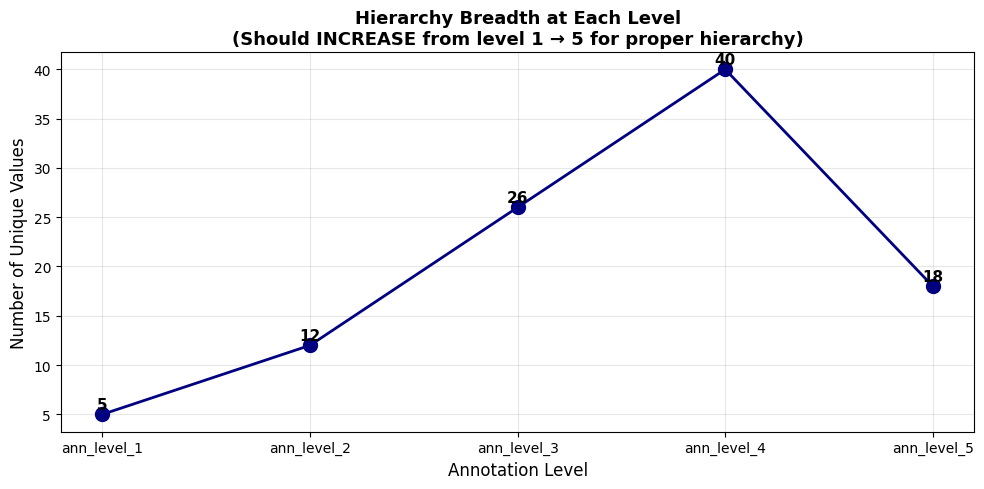


🔍 INTERPRETATION:
✅ CORRECT: Annotation levels increase in diversity (level 1 is broadest, level 5 is deepest)


In [3]:
print("\n" + "="*80)
print("ANNOTATION LEVEL DISTRIBUTION")
print("="*80)

level_stats = []

for level_col in sorted(ann_cols):
    unique_vals = ann_data[level_col].nunique()
    annotated_cells = ann_data[level_col].notna().sum()
    pct_annotated = (annotated_cells / len(ann_data)) * 100
    
    level_stats.append({
        'Level': level_col,
        'Unique Values': unique_vals,
        'Annotated Cells': annotated_cells,
        '% Annotated': pct_annotated
    })
    
    print(f"\n{level_col}:")
    print(f"  Unique values: {unique_vals}")
    print(f"  Annotated cells: {annotated_cells:,} ({pct_annotated:.1f}%)")
    
    # Show top values
    top_vals = ann_data[level_col].value_counts().head(5)
    for i, (val, count) in enumerate(top_vals.items(), 1):
        pct = (count / len(ann_data)) * 100
        print(f"    {i}. {val}: {count:,} ({pct:.1f}%)")

# Visualization
stats_df = pd.DataFrame(level_stats)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(stats_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stats_df['Level'], stats_df['Unique Values'], 'o-', linewidth=2, markersize=10, color='navy')
ax.set_xlabel('Annotation Level', fontsize=12)
ax.set_ylabel('Number of Unique Values', fontsize=12)
ax.set_title('Hierarchy Breadth at Each Level\n(Should INCREASE from level 1 → 5 for proper hierarchy)', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Add value labels
for i, row in stats_df.iterrows():
    ax.text(i, row['Unique Values'] + 0.5, str(int(row['Unique Values'])), 
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/hierarchy_breadth.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 INTERPRETATION:")
if stats_df.iloc[-1]['Unique Values'] > stats_df.iloc[0]['Unique Values']:
    print("✅ CORRECT: Annotation levels increase in diversity (level 1 is broadest, level 5 is deepest)")
else:
    print("❌ PROBLEM: Annotation levels do NOT increase monotonically in specificity")
    print("   This suggests reversed or non-monotonic levels")

## 3. Examine Example Annotation Paths

Show sample cells and their full annotation paths to understand the hierarchy structure.

In [4]:
print("\n" + "="*80)
print("SAMPLE ANNOTATION PATHS (n=20 cells)")
print("="*80)

# Get unique annotation paths
sample_indices = np.random.choice(len(ann_data), size=min(20, len(ann_data)), replace=False)

print(f"\n{'#':<3} {'ann_level_1':<20} {'ann_level_2':<25} {'ann_level_3':<25} {'ann_level_4':<20} {'ann_level_5':<15}")
print("-" * 130)

for idx, sample_idx in enumerate(sorted(sample_indices), 1):
    row = ann_data.iloc[sample_idx]
    path = [str(row[col]) if pd.notna(row[col]) else 'NA' for col in sorted(ann_cols)]
    print(f"{idx:<3} {path[0]:<20} {path[1]:<25} {path[2]:<25} {path[3]:<20} {path[4]:<15}")

# Show all unique paths
print("\n\n" + "="*80)
print("ALL UNIQUE ANNOTATION PATHS")
print("="*80)

unique_paths = ann_data.drop_duplicates().sort_values(by=sorted(ann_cols))
print(f"\nTotal unique paths: {len(unique_paths)}")
print(f"\n{'#':<3} {'ann_level_1':<20} {'ann_level_2':<25} {'ann_level_3':<25} {'ann_level_4':<20} {'ann_level_5':<15}")
print("-" * 130)

for idx, (_, row) in enumerate(unique_paths.iterrows(), 1):
    path = [str(row[col]) if pd.notna(row[col]) else 'NA' for col in sorted(ann_cols)]
    print(f"{idx:<3} {path[0]:<20} {path[1]:<25} {path[2]:<25} {path[3]:<20} {path[4]:<15}")


SAMPLE ANNOTATION PATHS (n=20 cells)

#   ann_level_1          ann_level_2               ann_level_3               ann_level_4          ann_level_5    
----------------------------------------------------------------------------------------------------------------------------------
1   Immune               Myeloid                   Macrophages               Unknown              Unknown        
2   Epithelial           Airway epithelium         Multiciliated lineage     Multiciliated        Multiciliated (non-nasal)
3   Endothelial          Blood vessels             EC capillary              EC general capillary NA             
4   Immune               Myeloid                   Monocytes                 Unknown              Unknown        
5   Immune               Myeloid                   Macrophages               Interstitial macrophages Monocyte-derived Mph
6   Immune               Myeloid                   Macrophages               Unknown              Unknown        
7   Immune   

## 4. Analyze Parent-Child Relationships

For each annotation level, determine which parent values map to which child values.

In [ ]:
print("\n" + "="*80)
print("PARENT-CHILD RELATIONSHIPS AT EACH LEVEL")
print("="*80)

# Analyze each transition
for i in range(len(sorted(ann_cols)) - 1):
    parent_col = sorted(ann_cols)[i]
    child_col = sorted(ann_cols)[i + 1]
    
    print(f"\n\n{'='*80}")
    print(f"{parent_col} → {child_col}")
    print(f"{'='*80}")
    
    # Get valid relationships (both parent and child are not NA)
    valid_rows = ann_data[(ann_data[parent_col].notna()) & (ann_data[child_col].notna())]
    
    parent_to_children = defaultdict(set)
    for _, row in valid_rows.iterrows():
        parent = row[parent_col]
        child = row[child_col]
        if parent != 'None' and child != 'None' and str(parent) != 'nan' and str(child) != 'nan':
            parent_to_children[parent].add(child)
    
    print(f"\nTotal parent categories: {len(parent_to_children)}")
    print(f"Total child categories: {len(set().union(*parent_to_children.values()))}")
    
    # Show hierarchy tree
    print(f"\n{'Parent':<35} {'→':<3} {'Children (count)':<60}")
    print("-" * 100)
    
    for parent in sorted(parent_to_children.keys()):
        children = sorted(parent_to_children[parent])
        children_parts = []
        for c in children[:3]:
            count = valid_rows[(valid_rows[parent_col]==parent) & (valid_rows[child_col]==c)].shape[0]
            children_parts.append(f"{c} ({count})")
        children_str = ", ".join(children_parts)
        if len(children) > 3:
            children_str += f", ... and {len(children)-3} more"
        
        print(f"{parent:<35} → {children_str:<60}")
    
    # Check for problematic patterns
    print(f"\n🔍 QUALITY CHECKS:")
    
    # Check if multiple parents map to same child
    child_to_parents = defaultdict(set)
    for parent, children in parent_to_children.items():
        for child in children:
            child_to_parents[child].add(parent)
    
    multi_parent_children = {child: parents for child, parents in child_to_parents.items() if len(parents) > 1}
    if multi_parent_children:
        print(f"⚠️  PROBLEM: {len(multi_parent_children)} children have multiple parents (many-to-many mapping)")
        for child, parents in list(multi_parent_children.items())[:3]:
            print(f"    {child} ← {parents}")
    else:
        print(f"✅ Each child has exactly one parent")
    
    # Check for cycles
    parent_child_pairs = [(p, c) for p, children in parent_to_children.items() for c in children]
    print(f"✅ Total parent-child relationships: {len(parent_child_pairs)}")

SyntaxError: f-string: unmatched ']' (1841288706.py, line 33)

## 5. Build Complete Hierarchy Tree

Build the complete parent-child hierarchy from level 1 to level 5.

In [ ]:
print("\n" + "="*80)
print("COMPLETE HIERARCHY TREE")
print("="*80)

# Build complete hierarchy
complete_hierarchy = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(set))))

for _, row in ann_data.dropna(subset=sorted(ann_cols)).iterrows():
    level1 = row['ann_level_1']
    level2 = row['ann_level_2']
    level3 = row['ann_level_3']
    level4 = row['ann_level_4']
    level5 = row['ann_level_5']
    
    if level1 and level2 and level3 and level4 and level5:
        complete_hierarchy[level1][level2][level3][level4].add(level5)

# Print tree
print(f"\nHierarchy with {len(complete_hierarchy)} roots:\n")

for level1 in sorted(complete_hierarchy.keys()):
    print(f"📦 {level1}")
    
    for level2 in sorted(complete_hierarchy[level1].keys()):
        print(f"  ├─ {level2}")
        
        for level3 in sorted(complete_hierarchy[level1][level2].keys()):
            print(f"  │  ├─ {level3}")
            
            for level4 in sorted(complete_hierarchy[level1][level2][level3].keys()):
                children = sorted(complete_hierarchy[level1][level2][level3][level4])
                children_str = ", ".join(children[:2])
                if len(children) > 2:
                    children_str += f" ... ({len(children)} total)"
                print(f"  │  │  ├─ {level4} → [{children_str}]")

# Count statistics
print(f"\n\n📊 HIERARCHY STATISTICS:")
print(f"{'Level 1':<20} {len(complete_hierarchy)} unique categories")
print(f"{'Level 2':<20} {sum(len(v) for v in complete_hierarchy.values())} unique categories")
print(f"{'Level 3':<20} {sum(len(v2) for v in complete_hierarchy.values() for v2 in v.values())} unique categories")
print(f"{'Level 4':<20} {sum(len(v3) for v in complete_hierarchy.values() for v2 in v.values() for v3 in v2.values())} unique categories")
print(f"{'Level 5':<20} {sum(len(v4) for v in complete_hierarchy.values() for v2 in v.values() for v3 in v2.values() for v4 in v3.values())} unique categories")

## 6. Identify Non-Monotonic Patterns

Detect where the hierarchy violates the expected monotonic increase in specificity.

In [ ]:
print("\n" + "="*80)
print("DETECTING NON-MONOTONIC PATTERNS")
print("="*80)

# For each cell, check if the same category appears at multiple levels
print(f"\n🔍 Checking for cells where same value appears at different levels...")

non_monotonic_count = 0
non_monotonic_examples = []

for _, row in ann_data.dropna(subset=sorted(ann_cols)).iterrows():
    values = [row[col] for col in sorted(ann_cols)]
    
    for i, val_i in enumerate(values):
        for j, val_j in enumerate(values):
            if i < j and val_i == val_j and val_i not in ['None', 'NA', 'nan']:
                non_monotonic_count += 1
                if len(non_monotonic_examples) < 10:
                    non_monotonic_examples.append({
                        'level_i': sorted(ann_cols)[i],
                        'level_j': sorted(ann_cols)[j],
                        'value': val_i,
                        'path': ' → '.join(values)
                    })

if non_monotonic_examples:
    print(f"\n⚠️  Found {non_monotonic_count} cases where same category appears at multiple levels")
    print(f"\nExamples of non-monotonic patterns:")
    for idx, ex in enumerate(non_monotonic_examples[:10], 1):
        print(f"\n{idx}. '{ex['value']}' appears at both {ex['level_i']} and {ex['level_j']}")
        print(f"   Full path: {ex['path']}")
else:
    print(f"\n✅ No non-monotonic patterns detected")

# Check for duplicate consecutive levels
print(f"\n\n🔍 Checking for cells with duplicate values in consecutive levels...")

duplicate_consecutive = 0
duplicate_consecutive_examples = []

for _, row in ann_data.dropna(subset=sorted(ann_cols)).iterrows():
    values = [row[col] for col in sorted(ann_cols)]
    
    for i in range(len(values) - 1):
        if values[i] == values[i+1] and values[i] not in ['None', 'NA', 'nan']:
            duplicate_consecutive += 1
            if len(duplicate_consecutive_examples) < 10:
                duplicate_consecutive_examples.append({
                    'level1': sorted(ann_cols)[i],
                    'level2': sorted(ann_cols)[i+1],
                    'value': values[i],
                    'path': ' → '.join(values)
                })

if duplicate_consecutive_examples:
    print(f"\n⚠️  Found {duplicate_consecutive} cases of duplicate values in consecutive levels")
    print(f"\nExamples:")
    for idx, ex in enumerate(duplicate_consecutive_examples[:5], 1):
        print(f"{idx}. {ex['level1']}='{ex['value']}' → {ex['level2']}='{ex['value']}'")
else:
    print(f"\n✅ No duplicate consecutive values")

# Summary
print(f"\n\n📊 SUMMARY:")
print(f"{'Total cells analyzed:':<30} {len(ann_data.dropna(subset=sorted(ann_cols)))}")
print(f"{'Non-monotonic occurrences:':<30} {non_monotonic_count}")
print(f"{'Duplicate consecutive:':<30} {duplicate_consecutive}")

## 7. Recommendations for Proper Hierarchy

Based on the analysis, provide recommendations for building a proper hierarchy.

In [ ]:
print("\n" + "="*80)
print("RECOMMENDATIONS FOR PROPER HIERARCHY STRUCTURE")
print("="*80)

recommendations = """
📋 FINDINGS AND RECOMMENDATIONS:

1. HIERARCHY STRUCTURE ANALYSIS:
   - Examine the "Annotation Level Distribution" chart above
   - If levels DON'T monotonically increase in unique values, the hierarchy is broken
   - The "Complete Hierarchy Tree" shows the actual structure in the data
   
2. SOLUTIONS (in order of preference):

   A. USE ONLY THE FINEST LEVEL (Recommended if levels are non-monotonic)
      ├─ Pros: Simple, no hierarchy issues, fast training
      ├─ Cons: Doesn't leverage hierarchical structure
      └─ Implementation: Use only 'ann_finest_level' annotation
   
   B. REVERSE THE ANNOTATION LEVELS
      ├─ If ann_level_1 has MOST unique values and ann_level_5 has LEAST:
      │  This suggests the levels are backwards
      │  Reverse them: use levels in order 5→4→3→2→1
      ├─ Pros: Maintains hierarchical structure correctly
      ├─ Cons: Requires verification that reversal makes semantic sense
      └─ Implementation: Swap annotation levels in processing
   
   C. MANUALLY DEFINE THE HIERARCHY
      ├─ Create a mapping: child → parent based on semantic knowledge
      ├─ Pros: Maximum control, semantically correct
      ├─ Cons: Labor-intensive
      └─ Implementation: Create ontology CSV with explicit parent-child pairs

3. NEXT STEPS:
   ✓ Review the "All Unique Annotation Paths" above
   ✓ Check if hierarchy makes semantic sense
   ✓ Decide on the best approach based on your understanding of the data
   ✓ Implement the chosen solution in the training notebook

4. KEY METRICS TO CHECK:
   - Does ann_level_1 have FEWER unique values than ann_level_5? (should be YES)
   - Do annotation paths make semantic sense? (e.g., Immune → T cells → CD8 T cells)
   - Are there any cells with duplicate values at different levels?
"""

print(recommendations)